<a href="https://colab.research.google.com/github/Beastaha/Trading-Bot-EPQ/blob/main/Strategy%2BBacktesting%2BBot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Defining strategy


In [ ]:
# Testing set of 5 weeks with aggregate results
# Need to test RR and EMAs and RSI
# STRATEGY SUBROUTINE

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta

def run_strategy(data, params):
    # Calculate indicators
    data.loc[:, 'EMA_short'] = data['Close'].ewm(span=params['ema_short'], adjust=False).mean()
    data['EMA_long'] = data['Close'].ewm(span=params['ema_long'], adjust=False).mean()

    def calculate_rsi(prices, period):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        return 100 - (100 / (1 + (gain/loss)))

    data['RSI'] = calculate_rsi(data['Close'], params['rsi_period'])

    # Signal generation
    data['Signal'] = 0
    cross_up = (data['EMA_short'] > data['EMA_long']) & (data['EMA_short'].shift(1) <= data['EMA_long'].shift(1))
    cross_down = (data['EMA_short'] < data['EMA_long']) & (data['EMA_short'].shift(1) >= data['EMA_long'].shift(1))

    for i in range(1, len(data)):
        if cross_up.iloc[i] and not cross_down.iloc[i]:
            data.at[i, 'Signal'] = 1
        elif cross_down.iloc[i] and not cross_up.iloc[i]:
            data.at[i, 'Signal'] = -1

    # RSI filtering
    data.loc[(data['Signal'] == 1) & (data['RSI'] > params['rsi_overbought']), 'Signal'] = 0
    data.loc[(data['Signal'] == -1) & (data['RSI'] < params['rsi_oversold']), 'Signal'] = 0

    # Trading simulation
    initial_capital = 10000
    capital = initial_capital
    position = 0
    entry_price = 0
    trade_results = []
    executed_indices = []

    for i in range(1, len(data)):
        current_price = data['Close'].iloc[i].item()

        if position == 0 and data['Signal'].iloc[i] != 0:
            executed_indices.append(i)
            if data['Signal'].iloc[i] == 1:  # Buy
                position = 1
                entry_price = current_price
                stop_loss = entry_price * (1 - params['stop_loss_pct'])
                take_profit = entry_price * (1 + params['take_profit_pct'])
            else:  # Sell
                position = -1
                entry_price = current_price
                stop_loss = entry_price * (1 + params['stop_loss_pct'])
                take_profit = entry_price * (1 - params['take_profit_pct'])

        elif position != 0:
            if (position == 1 and (current_price <= stop_loss or current_price >= take_profit)) or \
               (position == -1 and (current_price >= stop_loss or current_price <= take_profit)):
                exit_price = current_price
                pnl = (exit_price - entry_price)/entry_price * capital * position
                capital += pnl
                trade_results.append(pnl)
                position = 0

    return capital, trade_results, data, executed_indices

# Parameters (adjusted for 1h timeframe)
params = {
    "symbol": "^GSPC",
    "ema_short": 7,
    "ema_long": 30,
    "rsi_period": 30,
    "rsi_overbought": 70,
    "rsi_oversold": 30,
    "stop_loss_pct": 0.017,
    "take_profit_pct": 0.01
}

# Test weeks (now using 1h data)
test_weeks = [
    ("2024-01-08", "2024-01-12"),
    ("2024-03-04", "2024-03-08"),
    ("2024-05-06", "2024-05-10"),
    ("2024-08-05", "2024-08-09"),
    ("2024-10-07", "2024-10-11")
]

results = []
all_trades = []

for start, end in test_weeks:
    try:
        data = yf.download(
            params["symbol"],
            start=start,
            end=end,
            interval="1h",  # Changed to 1h
            auto_adjust=False,
            timeout=30
        )

        data = data[data['Volume'] > 0].copy()

        data.reset_index(inplace=True)
        data.loc[:, 'Datetime'] = pd.to_datetime(data['Datetime'])


        capital, trades, data, executed_indices = run_strategy(data, params)

        wins = len([x for x in trades if x > 0])
        losses = len(trades) - wins
        total_trades = len(trades)
        win_rate = wins/total_trades*100 if total_trades > 0 else 0
        pnl_pct = (capital/10000-1)*100

        results.append({
            "Week": f"{start} to {end}",
            "Trades": total_trades,
            "Wins": wins,
            "Losses": losses,
            "Win Rate (%)": f"{win_rate:.1f}",
            "PnL (%)": f"{pnl_pct:.2f}",
            "Final Capital": f"${capital:.2f}"
        })

        all_trades.extend(trades)

    except Exception as e:
        print(f"Error processing {start}-{end}: {str(e)}")
        continue

# Results table
if results:
    results_df = pd.DataFrame(results)
    print("\n=== Strategy Performance ===")
    print(results_df.to_string(index=False))

    if all_trades:
        total_wins = len([x for x in all_trades if x > 0])
        total_losses = len(all_trades) - total_wins
        avg_pnl = np.mean(all_trades)
        avg_win = np.mean([x for x in all_trades if x > 0]) if total_wins > 0 else 0
        avg_loss = np.mean([x for x in all_trades if x < 0]) if total_losses > 0 else 0
        profit_pct = abs(avg_win * total_wins / (avg_loss * total_losses)) if total_losses > 0 else np.inf

        print("\n=== Aggregate Statistics ===")
        print(f"Total Trades: {len(all_trades)}")
        print(f"Win Rate: {total_wins/len(all_trades)*100:.1f}%")
        print(f"Average PnL per Trade: ${avg_pnl:.2f}")
        print(f"Average Win: ${avg_win:.2f} | Average Loss: ${avg_loss:.2f}")
        print(f"Profit: {profit_pct:.2f}%")
        print(f"Max Win: ${max(all_trades):.2f} | Max Loss: ${min(all_trades):.2f}")
        print(f"Final Portfolio Value: ${10000 + sum(all_trades):.2f}")
else:
    print("No results generated - check data availability")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


=== Strategy Performance ===
                    Week  Trades  Wins  Losses Win Rate (%) PnL (%) Final Capital
2024-01-08 to 2024-01-12       1     1       0        100.0    1.23     $10122.55
2024-03-04 to 2024-03-08       0     0       0          0.0    0.00     $10000.00
2024-05-06 to 2024-05-10       1     1       0        100.0    1.02     $10101.59
2024-08-05 to 2024-08-09       1     1       0        100.0    1.01     $10101.13
2024-10-07 to 2024-10-11       0     0       0          0.0    0.00     $10000.00

=== Aggregate Statistics ===
Total Trades: 3
Win Rate: 100.0%
Average PnL per Trade: $108.42
Average Win: $108.42 | Average Loss: $0.00
Profit: inf%
Max Win: $122.55 | Max Loss: $101.13
Final Portfolio Value: $10325.26


[*********************100%***********************]  1 of 1 completed



=== Strategy Performance ===
Signals Generated: 20
Trades Completed: 20
Wins: 6 | Losses: 14
Win Rate: 30.0%
Final Capital: $10006.91 (0.07%)


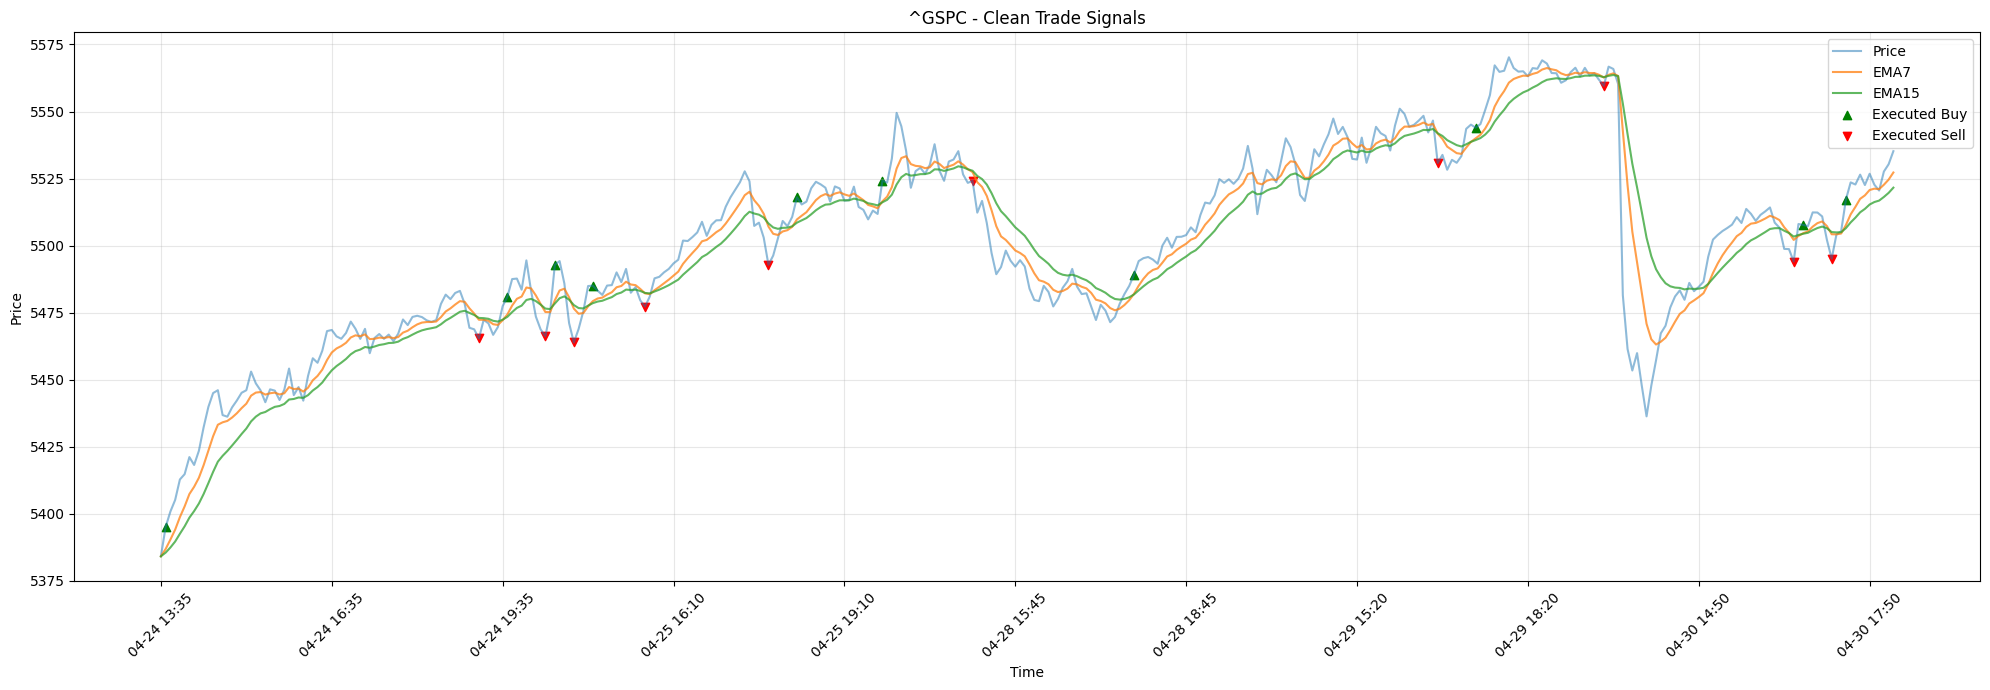

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Parameters
symbol = "^GSPC"
ema_short = 7
ema_long = 15
rsi_period = 14
rsi_overbought = 70
rsi_oversold = 30
stop_loss_pct = 0.001
take_profit_pct = 0.003

# Fetch and clean data
data = yf.download(symbol, period="5d", interval="5m", auto_adjust=False, timeout=30)
data = data[data['Volume'] > 0].dropna().reset_index(drop=False)
data['Datetime'] = pd.to_datetime(data['Datetime'])

# Calculate indicators
data['EMA_short'] = data['Close'].ewm(span=ema_short, adjust=False).mean()
data['EMA_long'] = data['Close'].ewm(span=ema_long, adjust=False).mean()

def calculate_rsi(prices, period):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    return 100 - (100 / (1 + (gain/loss)))

data['RSI'] = calculate_rsi(data['Close'], rsi_period)

# Signal generation with conflict resolution
data['Signal'] = 0
cross_up = (data['EMA_short'] > data['EMA_long']) & (data['EMA_short'].shift(1) <= data['EMA_long'].shift(1))
cross_down = (data['EMA_short'] < data['EMA_long']) & (data['EMA_short'].shift(1) >= data['EMA_long'].shift(1))

# Resolve conflicting signals
for i in range(1, len(data)):
    if cross_up.iloc[i] and not cross_down.iloc[i]:
        data.at[i, 'Signal'] = 1
    elif cross_down.iloc[i] and not cross_up.iloc[i]:
        data.at[i, 'Signal'] = -1

# RSI filtering
data.loc[(data['Signal'] == 1) & (data['RSI'] > rsi_overbought), 'Signal'] = 0
data.loc[(data['Signal'] == -1) & (data['RSI'] < rsi_oversold), 'Signal'] = 0

# Trading simulation
initial_capital = 10000
capital = initial_capital
position = 0
entry_price = 0
trade_results = []
executed_indices = []

for i in range(1, len(data)):
    current_price = data['Close'].iloc[i].item()

    if position == 0 and data['Signal'].iloc[i] != 0:
        executed_indices.append(i)
        if data['Signal'].iloc[i] == 1:  # Buy
            position = 1
            entry_price = current_price
            stop_loss = entry_price * (1 - stop_loss_pct)
            take_profit = entry_price * (1 + take_profit_pct)
        else:  # Sell
            position = -1
            entry_price = current_price
            stop_loss = entry_price * (1 + stop_loss_pct)
            take_profit = entry_price * (1 - take_profit_pct)

    elif position != 0:
        if (position == 1 and (current_price <= stop_loss or current_price >= take_profit)) or \
           (position == -1 and (current_price >= stop_loss or current_price <= take_profit)):
            exit_price = current_price
            pnl = (exit_price - entry_price)/entry_price * capital * position
            capital += pnl
            trade_results.append(pnl)
            position = 0

# Performance metrics
wins = len([x for x in trade_results if x > 0])
losses = len(trade_results) - wins
total_trades = len(trade_results)

# Plotting
plt.figure(figsize=(20, 7))
plot_index = range(len(data))

plt.plot(plot_index, data['Close'], label='Price', alpha=0.5)
plt.plot(plot_index, data['EMA_short'], label=f'EMA{ema_short}', alpha=0.75)
plt.plot(plot_index, data['EMA_long'], label=f'EMA{ema_long}', alpha=0.75)

# Plot executed signals with correct direction
buy_signals = [i for i in executed_indices if data['Signal'].iloc[i] == 1]
sell_signals = [i for i in executed_indices if data['Signal'].iloc[i] == -1]

plt.scatter(buy_signals, data.loc[buy_signals, 'Close'],
            marker='^', color='g', label='Executed Buy')
plt.scatter(sell_signals, data.loc[sell_signals, 'Close'],
            marker='v', color='r', label='Executed Sell')

# Formatting
ax = plt.gca()
ax.set_xticks(range(0, len(data), len(data)//10))
ax.set_xticklabels([data['Datetime'].iloc[x].strftime('%m-%d %H:%M') for x in ax.get_xticks()], rotation=45)
plt.title(f"{symbol} - Clean Trade Signals")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Performance report
print(f"\n=== Strategy Performance ===")
print(f"Signals Generated: {len(executed_indices)}")
print(f"Trades Completed: {total_trades}")
print(f"Wins: {wins} | Losses: {losses}")
print(f"Win Rate: {wins/total_trades*100:.1f}%" if total_trades > 0 else "Win Rate: 0%")
print(f"Final Capital: ${capital:.2f} ({((capital/initial_capital)-1)*100:.2f}%)")
plt.show()

# Finding optimal value combinations

In [ ]:
# BACKTESTING USING STRATEGY SUBROUTINE 30 TIMES WITH EMA CHANGING


def run_backtest(params):
    """
    Comprehensive backtesting function that takes parameters and returns results

    Args:
        params (dict): Dictionary containing all strategy parameters

    Returns:
        dict: Dictionary containing aggregated performance metrics
        pd.DataFrame: Detailed results per test week
        list: All individual trade results
    """
    # Test weeks configuration
    test_weeks = [
        ("2024-01-08", "2024-01-12"),
        ("2024-03-04", "2024-03-08"),
        ("2024-05-06", "2024-05-10"),
        ("2024-08-05", "2024-08-09"),
        ("2024-10-07", "2024-10-11")
    ]

    # Initialize results storage
    week_results = []
    all_trades = []

    for start, end in test_weeks:
        try:
            # Download data
            data = yf.download(
                params["symbol"],
                start=start,
                end=end,
                interval="1h",
                auto_adjust=False,
                timeout=30
            )

            # Clean data
            data = data[data['Volume'] > 0].copy()

            data.reset_index(inplace=True)
            data['Datetime'] = pd.to_datetime(data['Datetime'])

            # Run strategy
            capital, trades, data, _ = run_strategy(data, params)

            # Calculate metrics
            wins = len([x for x in trades if x > 0])
            losses = len(trades) - wins
            total_trades = len(trades)
            win_rate = wins/total_trades*100 if total_trades > 0 else 0
            pnl_pct = (capital/10000-1)*100

            week_results.append({
                "Week": f"{start} to {end}",
                "Trades": total_trades,
                "Wins": wins,
                "Losses": losses,
                "Win_Rate": win_rate,
                "PnL_Pct": pnl_pct,
                "Final_Capital": capital
            })

            all_trades.extend(trades)

        except Exception as e:
            print(f"Error processing {start}-{end}: {str(e)}")
            continue

    # Calculate aggregate statistics
    if all_trades:
        total_wins = len([x for x in all_trades if x > 0])
        total_losses = len(all_trades) - total_wins
        avg_pnl = np.mean(all_trades)
        avg_win = np.mean([x for x in all_trades if x > 0]) if total_wins > 0 else 0
        avg_loss = np.mean([x for x in all_trades if x < 0]) if total_losses > 0 else 0
        profit_factor = ((total_losses + total_wins) * avg_pnl) / 100

        aggregate_results = {
            "Total_Trades": len(all_trades),
            "Win_Rate": total_wins/len(all_trades)*100,
            "Avg_PnL": avg_pnl,
            "Avg_Win": avg_win,
            "Avg_Loss": avg_loss,
            "Profit_Factor": profit_factor,
            "Final_Value": 10000 + sum(all_trades),
            "Max_Win": max(all_trades) if all_trades else 0,
            "Max_Loss": min(all_trades) if all_trades else 0,
            "EMA_Short": params.get("ema_short", "N/A")  # Add EMA parameter for display
        }
    else:
        aggregate_results = {
            "Total_Trades": 0,
            "Win_Rate": 0,
            "Avg_PnL": 0,
            "Avg_Win": 0,
            "Avg_Loss": 0,
            "Profit_Factor": 0,
            "Final_Value": 10000,
            "Max_Win": 0,
            "Max_Loss": 0,
            "EMA_Short": params.get("ema_short", "N/A")
        }

    return aggregate_results, pd.DataFrame(week_results), all_trades


def format_results(agg_results, detailed_df, trades, profit_factors):
    """Helper function to format the output nicely"""
    #print("\n" + "="*60)
   # print(f"BACKTEST RESULTS FOR EMA_SHORT={agg_results.get('EMA_Short', 'N/A')}")
    #print("="*60 + "\n")

    # Format detailed results
    if not detailed_df.empty:
        detailed_df['Win_Rate'] = detailed_df['Win_Rate'].apply(lambda x: f"{x:.1f}%")
        detailed_df['PnL_Pct'] = detailed_df['PnL_Pct'].apply(lambda x: f"{x:.2f}%")
        detailed_df['Final_Capital'] = detailed_df['Final_Capital'].apply(lambda x: f"${x:,.2f}")

    #print("\nAggregate Statistics:")
    #print(f"• Final Portfolio Value: ${agg_results['Final_Value']:,.2f}")
    #print(f"• Total Profit/Loss: ${agg_results['Final_Value']-10000:,.2f}")
    #print(f"• Total Trades: {agg_results['Total_Trades']}")
    #print(f"• Win Rate: {agg_results['Win_Rate']:.1f}%")
    #print(f"• Avg PnL per Trade: ${agg_results['Avg_PnL']:,.2f}")
    #print(f"• Profit Factor: {agg_results['Profit_Factor']:.2f}")
    #print(f"• Max Win: ${agg_results['Max_Win']:,.2f} | Max Loss: ${agg_results['Max_Loss']:,.2f}")

    profit_factors.append(round(agg_results['Profit_Factor'], 2))

profit_factors = []
ema_short = 7
ema_long = 32
rsi_overbought = 100
rsi_oversold = 0


# for i in range(10):
#     # if ema_short == ema_long:
#     #   ema_short = 0
#     #   ema_long += 1
#     # if rsi_oversold == rsi_overbought:
#     #   rsi_oversold = 0
#     #   rsi_overbought -= 5


#     # ema_short += 1
#     # rsi_oversold += 5

#     params = {
#         "symbol": "^GSPC",
#         "ema_short": ema_short,
#         "ema_long": ema_long,
#         "rsi_period": 14,
#         "rsi_overbought": rsi_overbought,
#         "rsi_oversold": rsi_oversold,
#         "stop_loss_pct": 0.001
#         "take_profit_pct": 0.01
#     }
#     agg_results, detailed_df, trades = run_backtest(params)
#     format_results(agg_results, detailed_df, trades, profit_factors)

# profit_factors = [float(x) for x in profit_factors]


# ema_short = 0
# ema_long = 34
# rsi_overbought = 100
# rsi_oversold = 0


# for pct in profit_factors:

#     # if ema_short == ema_long:
#     #   ema_short = 0
#     #   ema_long += 1
#     #   print(f'EMA_Long: {ema_long}')

#     # ema_short += 1

#     # print(f"EMA_Short: {ema_short}, Profit Factor: {pct}")



#     # if rsi_oversold == rsi_overbought:
#     #   rsi_oversold = 0
#     #   rsi_overbought -= 5
#     #   print(f'RSI_Overbought: {rsi_overbought}')

#     # rsi_oversold += 5

#     # print(f'RSI_Oversold: {rsi_oversold}, Profit Factor: {pct}')

# ==============================================================================
# ==============================================================================
# ==============================================================================
# ==============================================================================
# ==============================================================================


# Run backtest for TP and SL as they need special handling for precision

from tqdm.notebook import tqdm

profit_factors = []
sl_start = 0.001  # 0.1%
tp_start = 0.001  # 0.1%
increment = 0.001 # 0.1%
max_val = 0.03    # 2%

# Calculate total iterations for progress bar
sl_values = [round(sl_start + i * increment, 4) for i in range(int((max_val - sl_start) / increment) + 1)]
tp_values = [round(tp_start + i * increment, 4) for i in range(int((max_val - tp_start) / increment) + 1)]
total_tests = len(sl_values) * len(tp_values)

test_count = 0

# Start progress bar
with tqdm(total=total_tests, desc="Backtesting Progress", unit="test") as pbar:
    for sl in sl_values:
        for tp in tp_values:
            params = {
                "symbol": "^GSPC",
                "ema_short": 7,
                "ema_long": 32,
                "rsi_period": 14,
                "rsi_overbought": 100,
                "rsi_oversold": 0,
                "stop_loss_pct": sl,
                "take_profit_pct": tp
            }

            # Run backtest
            agg_results, detailed_df, trades = run_backtest(params)
            pf = round(agg_results['Profit_Factor'], 2)
            profit_factors.append((sl, tp, pf))

            test_count += 1
            pbar.update(1)

print(f"\n✅ All {test_count} tests completed!")


Backtesting Progress:   0%|          | 0/400 [00:00<?, ?test/s]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********


✅ All 400 tests completed!


# Importing to spreadsheet

In [ ]:
# GOOGLE SHEETS EXPORT (Run this after your backtesting code)
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd

# Authenticate with Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Reconstruct the data_to_write list from your variables
data_to_write = []
ema_short = 0
ema_long = 34

for pct in profit_factors:
    if ema_short == ema_long:
        ema_short = 0
        ema_long += 1
    ema_short += 1
    data_to_write.append([ema_long, ema_short, pct])

# Create matrix structure
df = pd.DataFrame(data_to_write, columns=['EMA_Long', 'EMA_Short', 'Profit_Factor'])

# Pivot to create the matrix format
matrix_df = df.pivot(index='EMA_Long', columns='EMA_Short', values='Profit_Factor')

# Sort rows and columns
matrix_df = matrix_df.sort_index(axis=0).sort_index(axis=1)

# Create a new spreadsheet
sh = gc.create('EMA Backtest Results Matrix')
worksheet = sh.get_worksheet(0)

# Prepare header row
header = ['EMA_Long\EMA_Short'] + [f"{x}" for x in matrix_df.columns]
worksheet.update([header], 'A1')

# Prepare data rows
for i, (index, row) in enumerate(matrix_df.iterrows()):
    # Replace NaN with empty string and format numbers
    row_data = [f"{index}"] + [f"{x:.2f}" if pd.notnull(x) else "" for x in row]
    worksheet.update([row_data], f'A{i+2}')

print(f"Results saved to: {sh.url}")

Results saved to: https://docs.google.com/spreadsheets/d/1P28Lmj2P2ySb9AAHQVTi9GOv7gy84kxYIRRIM2e-i98


In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

# Authenticate with Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Extract unique SL and TP values
sl_values = sorted({x[0] for x in profit_factors})
tp_values = sorted({x[1] for x in profit_factors})

# Prepare headers (SLs)
headers = ['TP \\ SL'] + [f"{sl:.3f}" for sl in sl_values]

# Create new spreadsheet
sh = gc.create('TP-SL Results - Matrix Format')
worksheet = sh.get_worksheet(0)
worksheet.clear()

# Update headers
worksheet.update(values=[headers], range_name='A1')

# Write data rows (each row = TP, each column = SL)
for row_num, tp in enumerate(tp_values, start=2):
    row_data = [f"{tp:.3f}"]
    for sl in sl_values:
        # Find matching result or leave blank
        match = next((pf for s, t, pf in profit_factors if s == sl and t == tp), "")
        row_data.append(f"{match:.2f}" if match != "" else "")
    worksheet.update(values=[row_data], range_name=f'A{row_num}')

# Optional formatting
worksheet.format('A1:Z1', {'textFormat': {'bold': True}})
worksheet.format('A1:A100', {'textFormat': {'bold': True}})

print(f"✅ TP-SL Matrix exported successfully: {sh.url}")


✅ TP-SL Matrix exported successfully: https://docs.google.com/spreadsheets/d/100cRrYUbnKszeNvyxZbb5EbxaxLjXgLAqW5Yi3Dc6-s


# Bot Code


In [ ]:
#!pip install alpaca-trade-api


import alpaca_trade_api as tradeapi

# Replace with your actual Alpaca paper trading keys
API_KEY = 'PKA5IWGKPPJE58XYXWBM'
API_SECRET = 'ZWZjB196RFGkooFDgfrQb4wJmeY7hIsPdBUmp2hM'
BASE_URL = 'https://paper-api.alpaca.markets'

# Connect to the Alpaca API
api = tradeapi.REST(API_KEY, API_SECRET, BASE_URL, api_version='v2')

# Buy $1000 worth of SPY (ETF tracking the S&P 500)
symbol = 'SPY'
dollar_amount = 1250


# Get current market price of SPY
last_quote = api.get_latest_quote(symbol)
current_price = float(last_quote.ask_price or last_quote.bid_price)

# Estimate quantity to buy
estimated_qty = round(dollar_amount / current_price, 3)  # use 3 decimal places for fractional shares

# Submit market order with quantity
order = api.submit_order(
    symbol=symbol,
    qty=estimated_qty,
    side='buy',
    type='market',
    time_in_force='day'
)

print(f"Submitted order for approx. {estimated_qty} shares of {symbol} at ${current_price:.2f} ")


clock = api.get_clock()
if clock.is_open:
    print("Market is open. Order will be filled shortly.")
else:
    print("Market is closed. Order will be filled next trading session.")



Submitted order for approx. 2.201 shares of SPY at $567.92 
Market is open. Order will be filled shortly.


In [ ]:
# strategy.py
import yfinance as yf
import pandas as pd
import alpaca_trade_api as tradeapi
from datetime import datetime, timedelta

# — Alpaca setup —
API_KEY = 'PKA5IWGKPPJE58XYXWBM'
API_SECRET = 'ZWZjB196RFGkooFDgfrQb4wJmeY7hIsPdBUmp2hM'
BASE_URL = 'https://paper-api.alpaca.markets'
api        = tradeapi.REST(API_KEY, API_SECRET, BASE_URL, api_version='v2')

# — Strategy parameters —
SYMBOL         = "SPY"
EMA_SHORT      = 7
EMA_LONG       = 30
RSI_PERIOD     = 14
RSI_OVERBOUGHT = 70
RSI_OVERSOLD   = 30

# ↓↓↓ MODIFY THESE FOR SL/TP ↓↓↓
STOP_LOSS_PCT   = 0.017   # e.g. 0.015 = 1.5% stop-loss
TAKE_PROFIT_PCT = 0.01    # e.g. 0.02  = 2.0% take-profit


def fetch_data(symbol,
               start: str = None,
               end: str = None,
               lookback_days: int = 21,
               interval: str = "1h"):
    if start and end:
        df = yf.download(symbol, start=start, end=end, interval=interval)
    else:
        now   = datetime.utcnow()
        start = now - timedelta(days=lookback_days)
        df = yf.download(symbol,
                         start=start.strftime("%Y-%m-%d"),
                         end=now.strftime("%Y-%m-%d"),
                         interval=interval)
    df.dropna(inplace=True)
    return df


def calculate_rsi(prices, period):
    delta = prices.diff()
    gain  = delta.clip(lower=0).rolling(window=period).mean()
    loss  = -delta.clip(upper=0).rolling(window=period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))


def generate_signal(df):
    df['EMA_short'] = df['Close'].ewm(span=EMA_SHORT, adjust=False).mean()
    df['EMA_long']  = df['Close'].ewm(span=EMA_LONG,  adjust=False).mean()
    df['RSI']       = calculate_rsi(df['Close'], RSI_PERIOD)

    prev = df.iloc[-2]
    last = df.iloc[-1]

    cross_up   = (prev['EMA_short'] <= prev['EMA_long']).any() and (last['EMA_short'] > last['EMA_long']).any()
    cross_down = (prev['EMA_short'] >= prev['EMA_long']).any() and (last['EMA_short'] < last['EMA_long']).any()

    rsi_value     = df['RSI'].iloc[-1]
    rsi_condition = (rsi_value < RSI_OVERSOLD) or (rsi_value > RSI_OVERBOUGHT)

    if cross_up and not rsi_condition:
        return 'buy'
    if cross_down and not rsi_condition:
        return 'sell'
    return 'hold'


def submit_order(signal, dollar_amount=1000):
    if signal == 'hold':
        print("No trade signal.")
        return

    quote = api.get_latest_quote(SYMBOL)
    price = float(quote.ask_price or quote.bid_price)
    qty   = round(dollar_amount / price, 3)

    # calculate SL/TP prices
    if signal == 'buy':
        sl_price = round(price * (1 - STOP_LOSS_PCT), 2)
        tp_price = round(price * (1 + TAKE_PROFIT_PCT), 2)
    else:
        sl_price = round(price * (1 + STOP_LOSS_PCT), 2)
        tp_price = round(price * (1 - TAKE_PROFIT_PCT), 2)

    api.submit_order(
        symbol=SYMBOL,
        qty=qty,
        side=signal,
        type='market',
        time_in_force='gtc',
        order_class='bracket',
        stop_loss={'stop_price': sl_price},
        take_profit={'limit_price': tp_price}
    )
    print(f"{signal.upper()} order: {qty} shares @ ${price:.2f}, SL @ ${sl_price}, TP @ ${tp_price}")


In [ ]:
import time
from datetime import datetime

def run_hourly_bot():
    while True:
        now    = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        df     = fetch_data(SYMBOL)
        signal = generate_signal(df)
        print(f"[{now}] Signal → {signal}")
        submit_order(signal)
        time.sleep(3600)  # wait one hour

if __name__ == "__main__":
    run_hourly_bot()


[*********************100%***********************]  1 of 1 completed


[2025-04-30 17:37:17] Signal → hold
No trade signal.


KeyboardInterrupt: 